<a href="https://colab.research.google.com/github/Sarakazemi-prog/AIHC5020/blob/main/homework2_(7%2C8).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import numpy as np

def calculate_regression(x, y):
    # Check that both inputs are 1D NumPy arrays of floats
    if (not isinstance(x, np.ndarray) or
        not isinstance(y, np.ndarray) or
        x.ndim != 1 or
        y.ndim != 1 or
        x.dtype != float or
        y.dtype != float):
        print("invalid input")
        return None

    # Check that the arrays have the same length
    if len(x) != len(y):
        print("x and y are not the same length")
        return None

    # Create copies so the originals are unchanged
    x = x.copy()
    y = y.copy()

    # Replace missing values with the mean of each array
    x[np.isnan(x)] = np.nanmean(x)
    y[np.isnan(y)] = np.nanmean(y)

    # Find the means
    x_mean = np.mean(x)
    y_mean = np.mean(y)

    # Calculate the slope
    slope = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)

    # Calculate the intercept
    intercept = y_mean - slope * x_mean

    return slope, intercept


# ---------------- Test Cases ----------------

challenge_cases = [
    (np.array([1.0, 2.0, 4.0, 5.0]), np.array([1.0, 3.0, 3.0, 5.0])),
    (np.array([1.0, 2.0, 3.0, np.nan]), np.array([5.0, 4.0, np.nan, 2.0])),
    (np.array([1.0, 2.0]), np.array([1.0, 2.0, 3.0])),
    ([1.0, 2.0], np.array([3.0, 4.0])),
    (np.arange(4, dtype=float), np.array([5.0, 5.0, 5.0, 5.0])),
    (np.array([5.0, 5.0, 5.0, 5.0]), np.arange(4, dtype=float))
]

for i, case in enumerate(challenge_cases, start=1):
    print(f"Test Case {i}")
    result = calculate_regression(*case)
    print("Result:", result)
    print("-" * 40)

Test Case 1
Result: (np.float64(0.8), np.float64(0.5999999999999996))
----------------------------------------
Test Case 2
Result: (np.float64(-0.6666666666666667), np.float64(5.0))
----------------------------------------
Test Case 3
x and y are not the same length
Result: None
----------------------------------------
Test Case 4
invalid input
Result: None
----------------------------------------
Test Case 5
Result: (np.float64(0.0), np.float64(5.0))
----------------------------------------
Test Case 6
Result: (np.float64(nan), np.float64(nan))
----------------------------------------


/tmp/ipykernel_1419/3180475471.py:32: RuntimeWarning: invalid value encountered in scalar divide
  slope = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)


Test Case 1:


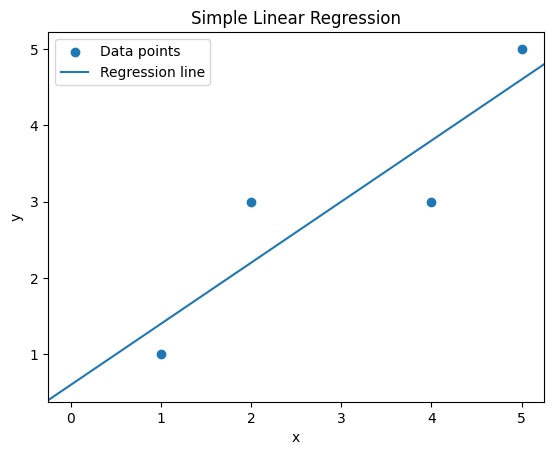

----------------------------------------
Test Case 2:


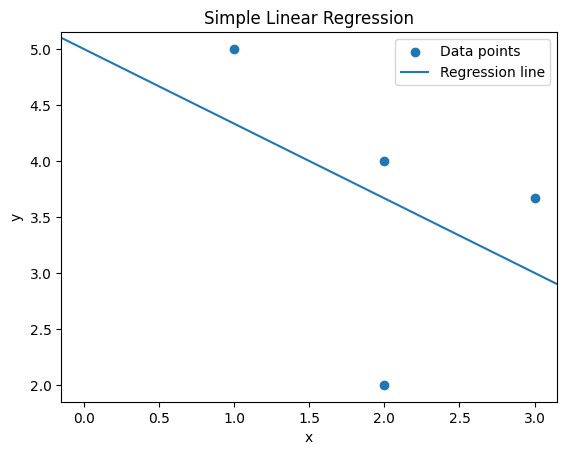

----------------------------------------
Test Case 3:
x and y are not the same length
----------------------------------------
Test Case 4:


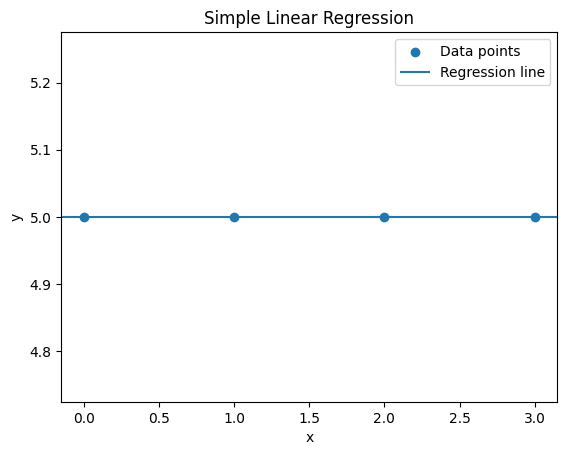

----------------------------------------
Test Case 5:
vertical line detected
----------------------------------------


In [13]:
# Problem 8

import numpy as np
import matplotlib.pyplot as plt


def calculate_regression(x, y):
    # Validate inputs
    if (not isinstance(x, np.ndarray) or
        not isinstance(y, np.ndarray) or
        x.ndim != 1 or
        y.ndim != 1 or
        x.dtype != float or
        y.dtype != float):
        print("invalid input")
        return None

    # Check that the arrays have the same length
    if len(x) != len(y):
        print("x and y are not the same length")
        return None

    # Create copies so the original arrays are unchanged
    x_copy = x.copy()
    y_copy = y.copy()

    # Replace missing values with the mean
    x_copy[np.isnan(x_copy)] = np.nanmean(x_copy)
    y_copy[np.isnan(y_copy)] = np.nanmean(y_copy)

    # Calculate the means
    x_mean = np.mean(x_copy)
    y_mean = np.mean(y_copy)

    # Calculate the slope numerator and denominator
    numerator = np.sum(
        (x_copy - x_mean) * (y_copy - y_mean)
    )

    denominator = np.sum(
        (x_copy - x_mean) ** 2
    )

    # Handle a vertical line
    if denominator == 0:
        return np.nan, np.nan

    slope = numerator / denominator
    intercept = y_mean - slope * x_mean

    return slope, intercept


def plot_regression(x, y):
    # Use the regression function from Problem 7
    result = calculate_regression(x, y)

    # Stop if the inputs are invalid
    if result is None:
        return None

    slope, intercept = result

    # Stop if the data form a vertical line
    if np.isnan(slope):
        print("vertical line detected")
        return None

    # Make copies for plotting
    x_plot = x.copy()
    y_plot = y.copy()

    # Replace missing values with the mean
    x_plot[np.isnan(x_plot)] = np.nanmean(x_plot)
    y_plot[np.isnan(y_plot)] = np.nanmean(y_plot)

    # Create the graph
    fig, ax = plt.subplots()

    ax.scatter(x_plot, y_plot, label="Data points")

    ax.axline(
        xy1=(0, intercept),
        slope=slope,
        label="Regression line"
    )

    ax.set_title("Simple Linear Regression")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()

    plt.show()


# Test cases must be outside both functions
challenge_cases = [
    (
        np.array([1.0, 2.0, 4.0, 5.0]),
        np.array([1.0, 3.0, 3.0, 5.0])
    ),
    (
        np.array([1.0, 2.0, 3.0, np.nan]),
        np.array([5.0, 4.0, np.nan, 2.0])
    ),
    (
        np.array([1.0, 2.0]),
        np.array([1.0, 2.0, 3.0])
    ),
    (
        np.arange(4, dtype=float),
        np.array([5.0, 5.0, 5.0, 5.0])
    ),
    (
        np.array([5.0, 5.0, 5.0, 5.0]),
        np.arange(4, dtype=float)
    )
]


# Run each test case
for i, (x, y) in enumerate(challenge_cases, start=1):
    print(f"Test Case {i}:")
    plot_regression(x, y)
    print("-" * 40)